<a href="https://colab.research.google.com/github/richa-kaplesh/MACHINE-LEARNING-PROJECT-1/blob/main/Expressions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/

In [14]:
!chmod 600 ~/.kaggle/kaggle.json

In [15]:
!kaggle datasets download -d msambare/fer2013
!unzip fer2013.zip -d /content/data


Streaming output truncated to the last 5000 lines.
  inflating: /content/data/train/sad/Training_65242339.jpg  
  inflating: /content/data/train/sad/Training_65267116.jpg  
  inflating: /content/data/train/sad/Training_65275626.jpg  
  inflating: /content/data/train/sad/Training_6529266.jpg  
  inflating: /content/data/train/sad/Training_65329617.jpg  
  inflating: /content/data/train/sad/Training_65338712.jpg  
  inflating: /content/data/train/sad/Training_65338797.jpg  
  inflating: /content/data/train/sad/Training_65387162.jpg  
  inflating: /content/data/train/sad/Training_65404494.jpg  
  inflating: /content/data/train/sad/Training_65426218.jpg  
  inflating: /content/data/train/sad/Training_65430136.jpg  
  inflating: /content/data/train/sad/Training_65437377.jpg  
  inflating: /content/data/train/sad/Training_6545735.jpg  
  inflating: /content/data/train/sad/Training_65463385.jpg  
  inflating: /content/data/train/sad/Training_65473985.jpg  
  inflating: /content/data/train/sad

In [16]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = "/content/data/train"

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(48, 48),
    batch_size=64,
    color_mode="grayscale",
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(48, 48),
    batch_size=64,
    color_mode="grayscale",
    class_mode="categorical",
    subset="validation"
)


Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.


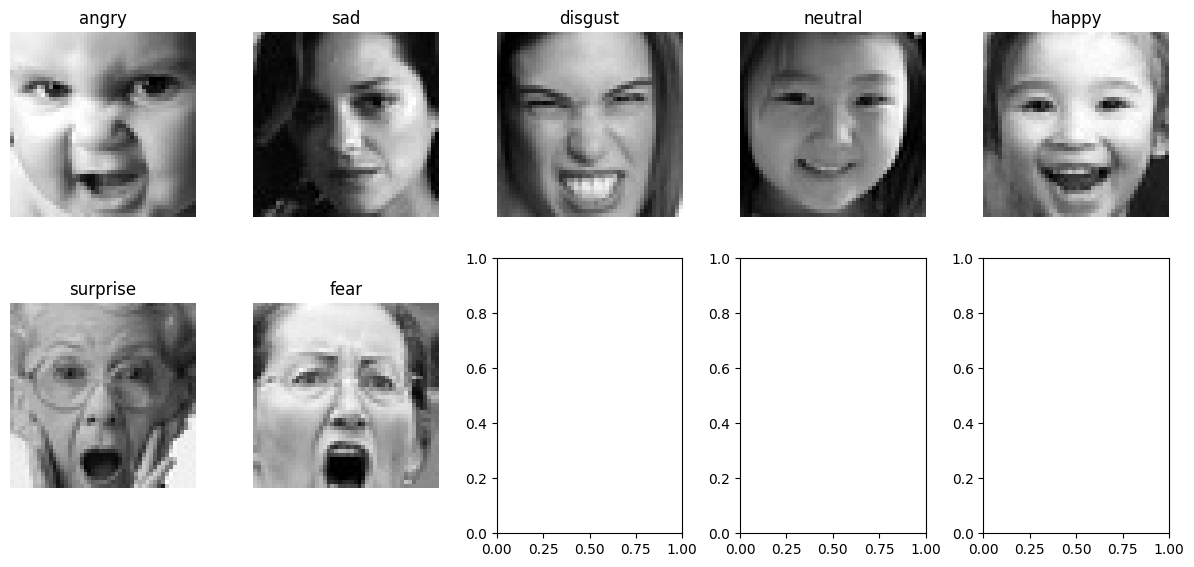

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

# Path to dataset
dataset_path = "/content/data/train"

# Get emotion labels (folder names)
emotion_labels = os.listdir(dataset_path)

# Display sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for i, emotion in enumerate(emotion_labels[:10]):  # Show first 10 categories
    emotion_path = os.path.join(dataset_path, emotion)
    image_name = os.listdir(emotion_path)[0]  # Pick the first image from the folder
    image_path = os.path.join(emotion_path, image_name)

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Read image in grayscale
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(emotion)
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(48, 48, 1)),
    MaxPooling2D(2,2),


    Conv2D(128, (3,3), activation='relu'),
    Dropout(0.5),

    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),


    Conv2D(512, (3,3), activation='relu'),


    Flatten(),
    Dense(256, activation='relu'),

    Dense(7, activation='softmax')  # 7 emotions
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Show model summary
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)                   │ (None, 46, 46, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 21, 21, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 21, 21, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 19, 19, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 9, 9, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 7, 7, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 7)                   │           1,799 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,974,407 (30.42 MB)

 Trainable params: 7,974,407 (30.42 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = model.fit(train_data, validation_data=val_data, epochs=30)


Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9330 - loss: 0.1969 - val_accuracy: 0.5349 - val_loss: 2.5230
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9360 - loss: 0.1870 - val_accuracy: 0.5222 - val_loss: 2.7970
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9396 - loss: 0.1799 - val_accuracy: 0.5325 - val_loss: 2.8378
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9450 - loss: 0.1628 - val_accuracy: 0.5337 - val_loss: 2.9050
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.9460 - loss: 0.1539 - val_accuracy: 0.5379 - val_loss: 3.0611
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9464 - loss: 0.1507 - val_accuracy: 0.5372 - val_loss: 3.0908
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9526 - loss: 0.1413 - val_accuracy: 0.5372 - val_loss: 2.8984
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.9583 - loss: 0.1204 - 

In [29]:
model.save("/content/drive/MyDrive/emotion_model.h5")
